In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
lv_library = pd.read_csv("Louisville_Library_Inventory_List.csv")

print(lv_library.head())

    BibNum                                              Title  \
0   707409  Jeff Immelt and the new GE way : innovation, t...   
1  1341361           McGraw-Hill's American idioms dictionary   
2   707411  Robin rescues dinner : 52 weeks of quick-fix m...   
3  1341362  McGraw-Hill's essential ESL grammar : a handbo...   
4   707411  Robin rescues dinner : 52 weeks of quick-fix m...   

                 Author                ISBN   PublicationYear ItemType  \
0   Magee, David, 1965-   9,780,071,605,878              2009     Book   
1    Spears, Richard A.   9,780,071,478,939              2007     Book   
2  Miller, Robin, 1964-   9,780,307,451,408              2009     Book   
3         Lester, Mark.   9,780,071,496,421              2008     Book   
4  Miller, Robin, 1964-   9,780,307,451,408              2009     Book   

      ItemCollection   ItemLocation  ItemPrice              ReportDate  \
0  Adult Non-Fiction           Main      25.95  2022/07/01 04:00:00+00   
1     ELL Collec

In [31]:
lv_library = lv_library.drop(columns = ['BibNum', 'ObjectId', 'ReportDate']) # deleted unnecassary columns

In [32]:
lv_library.duplicated().sum() # checked duplicated row and drop dublications
lv_library = lv_library.drop_duplicates()

In [ ]:
lv_library.dtypes # checked data types

Title               object
Author              object
 ISBN               object
PublicationYear      int64
ItemType            object
ItemCollection      object
ItemLocation        object
ItemPrice          float64
dtype: object

In [ ]:
# copied original dataset
# converted data types 
lv_library = lv_library.copy()

lv_library['Title'] = lv_library['Title'].astype('string')
lv_library['Author'] = lv_library['Author'].astype('string')
lv_library[' ISBN '] = lv_library[' ISBN '].astype('string')
lv_library['PublicationYear'] = pd.to_numeric(lv_library['PublicationYear'], errors= 'coerce')
lv_library['ItemType'] = lv_library['ItemType'].astype('category')
lv_library['ItemCollection'] = lv_library['ItemCollection'].astype('category')
lv_library['ItemLocation'] = lv_library['ItemLocation'].astype('category')
lv_library['ItemPrice'] = pd.to_numeric(lv_library['ItemPrice'], errors= 'coerce')

In [ ]:
# renamed a column name
lv_library = lv_library.rename(columns={' ISBN ' : 'ISBN'}) 
lv_library.columns

Index(['Title', 'Author', 'ISBN', 'PublicationYear', 'ItemType',
       'ItemCollection', 'ItemLocation', 'ItemPrice'],
      dtype='object')

In [78]:
# filled missin values

lv_library['Author'] = lv_library['Author'].fillna('Unknown')

lv_library['ISBN'] = lv_library['ISBN'].replace('', pd.NA)

lv_library['PublicationYear'] = lv_library['PublicationYear'].fillna(0)

In [ ]:
# Create new columns

lv_library['ItemAge'] = 2026 - lv_library['PublicationYear']
lv_library['PriceCategory'] = pd.cut(lv_library['ItemPrice'],
                             bins=[0, 10, 25, 50, 100, float('inf')],
                             labels = ['$0-10', '$10-25', '$25-50', '$50-100', '$100+'])
lv_library.columns

Index(['Title', 'Author', 'ISBN', 'PublicationYear', 'ItemType',
       'ItemCollection', 'ItemLocation', 'ItemPrice', 'ItemAge',
       'PriceCategory'],
      dtype='object')

In [64]:
lv_library.head()

,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ItemAge,PriceCategory
0,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-","9,780,071,605,878",2009,Book,Adult Non-Fiction,Main,25.95,17,$25-50
1,McGraw-Hill's American idioms dictionary,"Spears, Richard A.","9,780,071,478,939",2007,Book,ELL Collection,South Central,20.00,19,$10-25
2,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-","9,780,307,451,408",2009,Book,Adult Non-Fiction,Southwest,19.99,17,$10-25
3,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.","9,780,071,496,421",2008,Book,ELL Collection,South Central,20.00,18,$10-25
5,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-","9,780,307,451,408",2009,Book,Adult Non-Fiction,Remote Shelving - Main,19.99,17,$10-25


In [ ]:
# Cleaned ItemType column

lv_library['ItemType'].unique()
lv_library['ItemType'].value_counts()

['Book', 'Audio Book on CD', 'DVD', 'Ebook', 'Music CD', ..., 'Videotape', 'Archival/Mixed Materials', 'Projected Medium', 'Manuscript Music', 'Blu-ray + DVD']
Length: 35
Categories (35, object): ['Archival/Mixed Materials', 'Atlas', 'Audio Book on CD', 'Audio Books', ..., 'Three Dimensional Object (Artifact)', 'Two Dimensional Nonprojected Graphic', 'Videorecording', 'Videotape']

In [73]:
books = ['Book', 'Large Print', 'Printed Music', 'Atlas', 'Printed Cartographic Material', 'Braille', 'Manuscript Material', 'Serial', 'Microform', 'Archival/Mixed Materials', 'Manuscript Music']

audiobooks = ['Audio Book on CD', 'Audio Books', 'Eaudiobook']

music = ['Music CD', 'Musical Sound Recording', 'Sound Recording', 'Streaming Music']
video =['DVD', 'Blue-ray Disc', 'Videorecording', 'Videotape', 'Streaming Video']
digital = ['Ebook', 'Emagazine', 'Electronic Resources']
mixed_media = ['Book + DVD', 'Book + CD', 'Kit', 'Three Dimensional Object (Artifact)' ]
other = ['Two Dimensional Nonprojected Graphic', 'Map', 'Recorded Events', 'Projected Medium']





In [74]:
# it has 35 diffrent item types and seems like some of the almost same. Therefore, I decided to mapping it.
def categorize_itemtype(x):
    if x in books:
        return 'Book'
    if x in audiobooks:
        return 'Audiobook'
    if x in music:
        return 'Music'
    if x in video:
        return 'Video'
    if x in digital:
        return 'Digital Reading'
    if x in mixed_media:
        return 'Mixed_media'
    return 'Other'


lv_library['ItemTypeClean'] = lv_library['ItemType'].apply(categorize_itemtype)
    

In [76]:
lv_library.columns
lv_library.shape

(886428, 11)

GROUPNG

In [ ]:
lv_library.groupby('ItemTypeClean').size().sort_values(ascending=False)

ItemTypeClean
Book               722322
Video               47525
Audiobook           41541
Digital Reading     40076
Music               32617
Other                1309
Mixed_media          1038
dtype: int64

In [84]:
lv_library.groupby('PublicationYear').size().sort_index()

PublicationYear
0       4448
120        1
997        2
1011       1
1554       1
        ... 
2022    3642
2050       1
2099       1
5124       1
9999       2
Length: 302, dtype: int64

In [88]:
lv_library.groupby('ItemLocation').size().sort_values(ascending= False)

C:\Users\vbyam\AppData\Local\Temp\ipykernel_13676\1542457945.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lv_library.groupby('ItemLocation').size().sort_values(ascending= False)


ItemLocation
Main                         173715
Remote Shelving - Main       117820
South Central                 83844
Southwest                     81120
Northeast                     66072
Bon Air                       52115
St Matthews                   43304
Jeffersontown                 40293
Iroquois                      37583
Highlands - Shelby Park       27936
Crescent Hill                 27783
Childrens Main Library        24403
Fairdale                      17921
Newburg                       16321
Shively                       15635
Western                       14027
Shawnee                       13339
Middletown                    10890
Portland                       7504
Remote Shelving - Shawnee      7086
Main Teen                      4014
Childrens Bookmobile           3697
Content Management                3
Adult Bookmobile                  3
dtype: int64

In [99]:
lv_library.groupby('Title')['PublicationYear'].size().sort_values(ascending=False).head(20)

Title
Selected poems                                              128
Greatest hits                                               114
Annual report.                                              108
Home                                                         80
Burn                                                         79
Cinderella                                                   78
The night before Christmas                                   77
The World almanac and book of facts.                         75
Fallout                                                      74
Haunted                                                      74
Kentucky                                                     70
Rand McNally road atlas : United States, Canada, Mexico.     69
Annual report                                                69
The girl on the train                                        68
Macbeth                                                      67
Poems                             

In [102]:
lv_library.sort_values('PublicationYear').head(5)
lv_library.sort_values('PublicationYear', ascending=False).head(5)

,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ItemAge,PriceCategory,ItemTypeClean
299609,Residual life assessment of major light water ...,Unknown,<NA>,9999,Book,Government Documents,Main,75.00,-7973,$50-100,Book
725313,The Greene murder case : a Philo Vance story,"Van Dine, S. S.",<NA>,9999,Book,Mystery,Main,14.95,-7973,$10-25,Book
731136,Annual report of the Louisville City Hospital.,"Louisville City Hospital (Louisville, Ky.)",<NA>,5124,Serial,Kentucky History,Main,2.00,-3098,$0-10,Book
756230,Everything Will Be Okay,"Perino, Dana","9,781,538,708,873",2099,Ebook,Electronic,Main,0.00,-73,NaN,Digital Reading
30527,The Shift,"Johnson, Tory","9,780,316,286,626",2050,Ebook,Electronic,Main,0.00,-24,NaN,Digital Reading


In [103]:
lv_library.groupby('ItemTypeClean')['ItemPrice'].mean()

ItemTypeClean
Audiobook           38.312732
Book                21.558739
Digital Reading      0.022108
Mixed_media        137.277640
Music               13.788262
Other               16.263545
Video               17.344955
Name: ItemPrice, dtype: float64

CHARTS

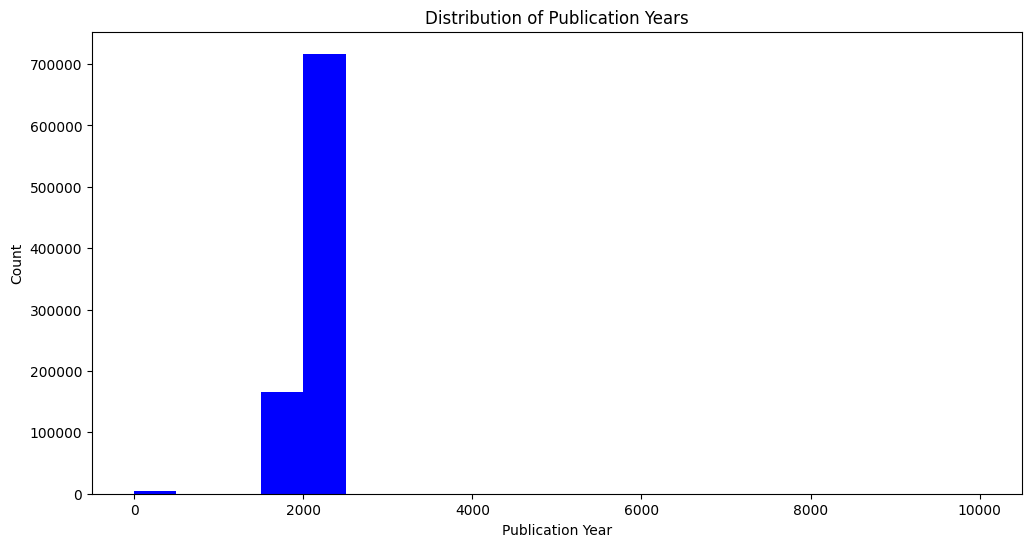

In [111]:
plt.figure(figsize=(12,6)) 
plt.hist(lv_library["PublicationYear"], bins=20, color= 'blue') 
plt.title("Distribution of Publication Years") 
plt.xlabel("Publication Year") 
plt.ylabel("Count") 
plt.show()

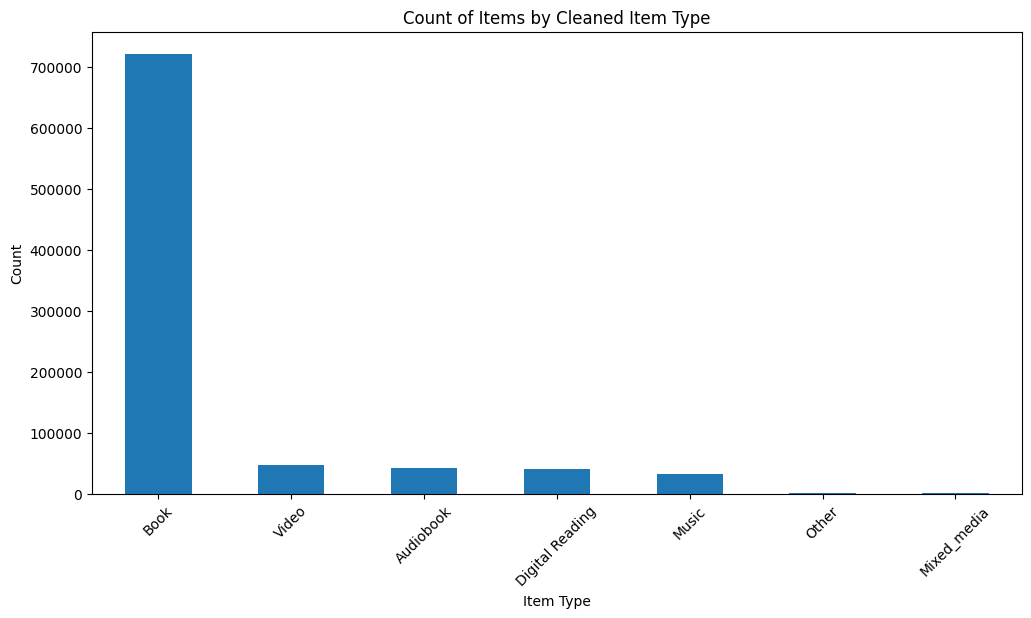

In [110]:
plt.figure(figsize=(12,6)) 
lv_library["ItemTypeClean"].value_counts().plot(kind="bar") 
plt.title("Count of Items by Cleaned Item Type") 
plt.xlabel("Item Type") 
plt.ylabel("Count") 
plt.xticks(rotation=45) 
plt.show()

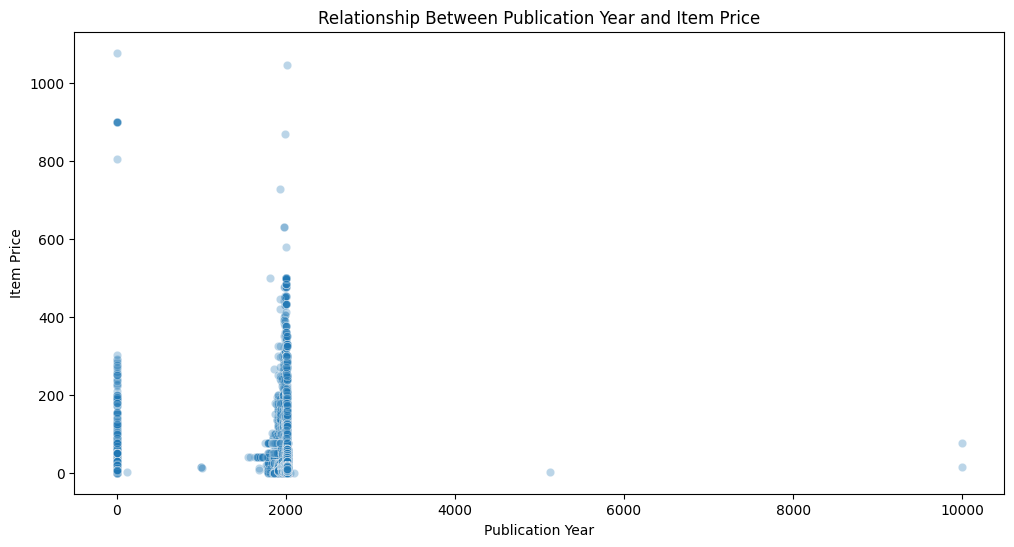

In [112]:
plt.figure(figsize=(12,6)) 
sns.scatterplot( data=lv_library, x="PublicationYear", y="ItemPrice", alpha=0.3 ) 
plt.title("Relationship Between Publication Year and Item Price") 
plt.xlabel("Publication Year") 
plt.ylabel("Item Price") 
plt.show()